## Module 2 : Finding Neutral Atom Qubit Gates
### Exercise 2-4 : CZ-gate realization with Time-Optimal Gates
Problem Unsolved : 
- the meaning of populations in FIG.3.

In [1]:
%reload_ext autoreload
%autoreload 2

from Default_TQCONFIG_for_CZ_GATE_TO import *

#### Initial state & Monitered Operators

In [8]:
# initial state
psi0 = two_atom_fock_states[0][1]  # |1,1>

# list of wanted operators 
# Note : ground state is the initial state, not always |0,0>
# Pg : one atom ground state : |0><0| ⊗ I + I ⊗ |0><0|
# Pg = tensor(state0 * state0.dag(), Qobj(np.eye(4))) + tensor(Qobj(np.eye(4)), state0 * state0.dag())
Pg = psi0 * psi0.dag()
# Pr : one atom Rydberg state : |r><r| ⊗ I + I ⊗ |r><r|
Pr = tensor(stater * stater.dag(), Qobj(np.eye(4))) + tensor(Qobj(np.eye(4)), stater * stater.dag())

# Pgg : two atom ground state : |0,0><0,0|
P_gg = psi0 * psi0.dag()
# P_gr : single excited Rydberg state with another atom in ground state : |r,0><r,0| + |r,1><r,1| + |0,r><0,r| + |1,r><1,r|
P_gr = two_atom_fock_states[2][0] * two_atom_fock_states[2][0].dag() \
      + two_atom_fock_states[2][1] * two_atom_fock_states[2][1].dag() \
      + two_atom_fock_states[0][2] * two_atom_fock_states[0][2].dag() \
      + two_atom_fock_states[1][2] * two_atom_fock_states[1][2].dag()
# Prr : double Rydberg state : |r,r><r,r|
P_rr = two_atom_fock_states[2][2] * two_atom_fock_states[2][2].dag()


expect_op_list = [
  Pg,
  Pr,
  P_gg,
  P_gr,
  P_rr
]

In [9]:
# construct the total Hamiltonian
Htotal, collapse_list = construct_TD_TAHam(atom0_ham_params, atom1_ham_params, 
                                           lindblad_params, lindblad_params, Rydberg_B)

# simulate the dynamics
result = mesolve(Htotal, psi0, tlist, collapse_list, expect_op_list, 
                 options={"store_final_state": 1, "store_states": 0})

<Axes: title={'center': 'Rydberg gate simulation with time-optimal pulse'}, xlabel='Time ($\\mu$s)', ylabel='Population'>

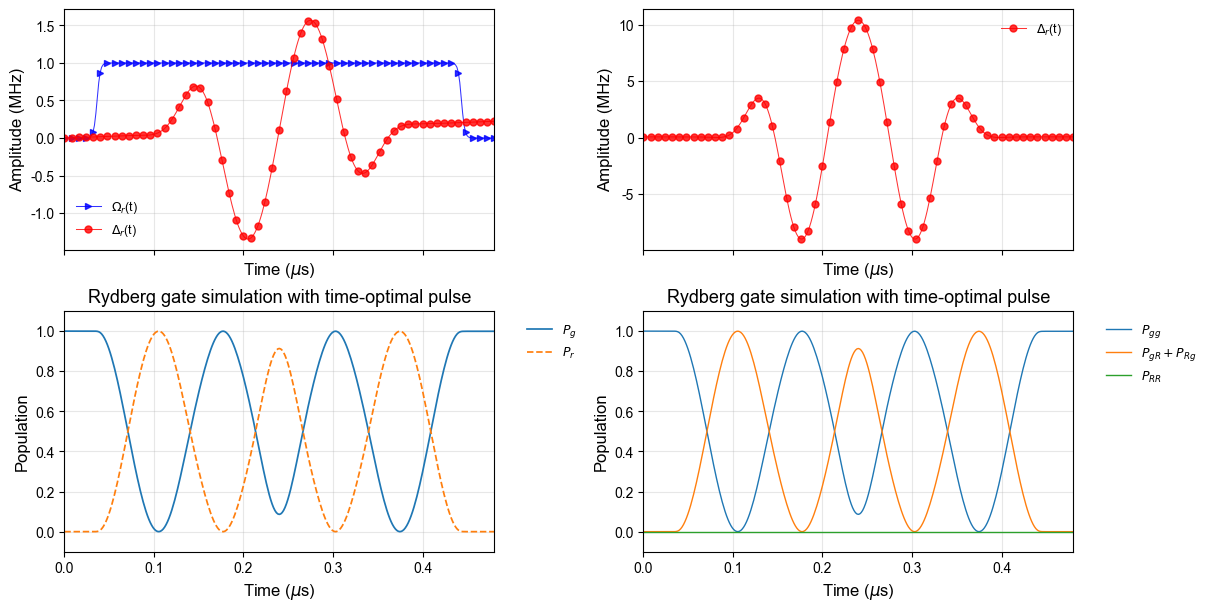

In [10]:
plotting_styles["Omega_r_pulse"]["markevery"] = 5
plotting_styles["Delta_r_pulse"]["markevery"] = 5
plt.rcParams.update(plt_config)

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=False, constrained_layout=True)
axes = axes.ravel()
# Plot the pulse shapes
pulse_dict = {
  'Omega_r': {'data': time_optimal_pulse_Omega_r, 'args': Omega_r_pulse_args, 
              'label': r'$\Omega_r$(t)', 'style': 'Omega_r_pulse', 'normalize_factor': amp_Omega_r},
  'Delta_r': {'data': time_optimal_pulse_phase_profile, 'args': Delta_r_pulse_args, 
              'label': r'$\Delta_r$(t)', 'style': 'Delta_r_pulse', 'normalize_factor': 1.0}
}

plot_pulse_shapes(
  ax = axes[0],
  tlist = tlist,
  pulse_dict = pulse_dict,
  title = None,
  xlabel = r"Time ($\mu$s)",
  ylabel = "Amplitude (MHz)",
  normalize_2pi = False,  # 使用每个脉冲自己的 normalize_factor
  ylim = None,
  grid_alpha = 0.3,
  # legend_config = legend_styles['compact'],
)

# Plot the pulse shapes of Delta_r
pulse_dict = {
  'Delta_r': {'data': time_optimal_pulse_Delta_r, 'args': Delta_r_pulse_args, 
              'label': r'$\Delta_r$(t)', 'style': 'Delta_r_pulse', 'normalize_factor': 2 * np.pi}
}

plot_pulse_shapes(
  ax = axes[1],
  tlist = tlist,
  pulse_dict = pulse_dict,
  title = None,
  xlabel = r"Time ($\mu$s)",
  ylabel = "Amplitude (MHz)",
  normalize_2pi = False,  # 使用每个脉冲自己的 normalize_factor
  ylim = None,
  grid_alpha = 0.3,
  # legend_config = legend_styles['compact'],
)
  
# Plot the population evolution
pop_list = [result.expect[0], result.expect[1]]
legend_list = [r"$P_g$", r"$P_r$"]

plot_population_evolution(
  ax = axes[2],
  tlist = tlist,
  pop_list = pop_list,
  legend_list = legend_list,
  plot_pulse = False,
  pulse_dict = {},
  title = r"Rydberg gate simulation with time-optimal pulse",
  xlabel = r"Time ($\mu$s)",
  ylabel = "Population",
  log_scale = False,
  xlim = None,
  ylim = None,
  grid_alpha = 0.3,
  show_legend = True,
  plotting_style_list = None,
)

# Plot the population evolution
pop_list = [result.expect[2], result.expect[3], result.expect[4]]
legend_list = [r"$P_{gg}$", r"$P_{gR} + P_{Rg}$", r"$P_{RR}$"]

plot_population_evolution(
  ax = axes[3],
  tlist = tlist,
  pop_list = pop_list,
  legend_list = legend_list,
  plot_pulse = False,
  pulse_dict = {},
  title = r"Rydberg gate simulation with time-optimal pulse",
  xlabel = r"Time ($\mu$s)",
  ylabel = "Population",
  log_scale = False,
  xlim = None,
  ylim = None,
  grid_alpha = 0.3,
  show_legend = True,
  plotting_style_list = [plotting_styles["pop_style_a"]],
)


In [5]:
# initial state
psi0 = two_atom_fock_states[1][1]  # |1,1>

# list of wanted operators 
# Note : ground state is the initial state, not always |0,0>
# Pg : one atom ground state : |0><0| ⊗ I + I ⊗ |0><0|
# Pg = tensor(state0 * state0.dag(), Qobj(np.eye(4))) + tensor(Qobj(np.eye(4)), state0 * state0.dag())
Pg = psi0 * psi0.dag()
# Pr : one atom Rydberg state : |r><r| ⊗ I + I ⊗ |r><r|
Pr = tensor(stater * stater.dag(), Qobj(np.eye(4))) + tensor(Qobj(np.eye(4)), stater * stater.dag())

# Pgg : two atom ground state : |0,0><0,0|
P_gg = psi0 * psi0.dag()
# P_gr : single excited Rydberg state with another atom in ground state : |r,0><r,0| + |r,1><r,1| + |0,r><0,r| + |1,r><1,r|
P_gr = two_atom_fock_states[2][0] * two_atom_fock_states[2][0].dag() \
      + two_atom_fock_states[2][1] * two_atom_fock_states[2][1].dag() \
      + two_atom_fock_states[0][2] * two_atom_fock_states[0][2].dag() \
      + two_atom_fock_states[1][2] * two_atom_fock_states[1][2].dag()
# Prr : double Rydberg state : |r,r><r,r|
P_rr = two_atom_fock_states[2][2] * two_atom_fock_states[2][2].dag()


expect_op_list = [
  Pg,
  Pr,
  P_gg,
  P_gr,
  P_rr
]

In [6]:
# construct the total Hamiltonian
Htotal, collapse_list = construct_TD_TAHam(atom0_ham_params, atom1_ham_params, 
                                           lindblad_params, lindblad_params, Rydberg_B)

# simulate the dynamics
result = mesolve(Htotal, psi0, tlist, collapse_list, expect_op_list, 
                 options={"store_final_state": 1, "store_states": 0})

<Axes: title={'center': 'Rydberg gate simulation with time-optimal pulse'}, xlabel='Time ($\\mu$s)', ylabel='Population'>

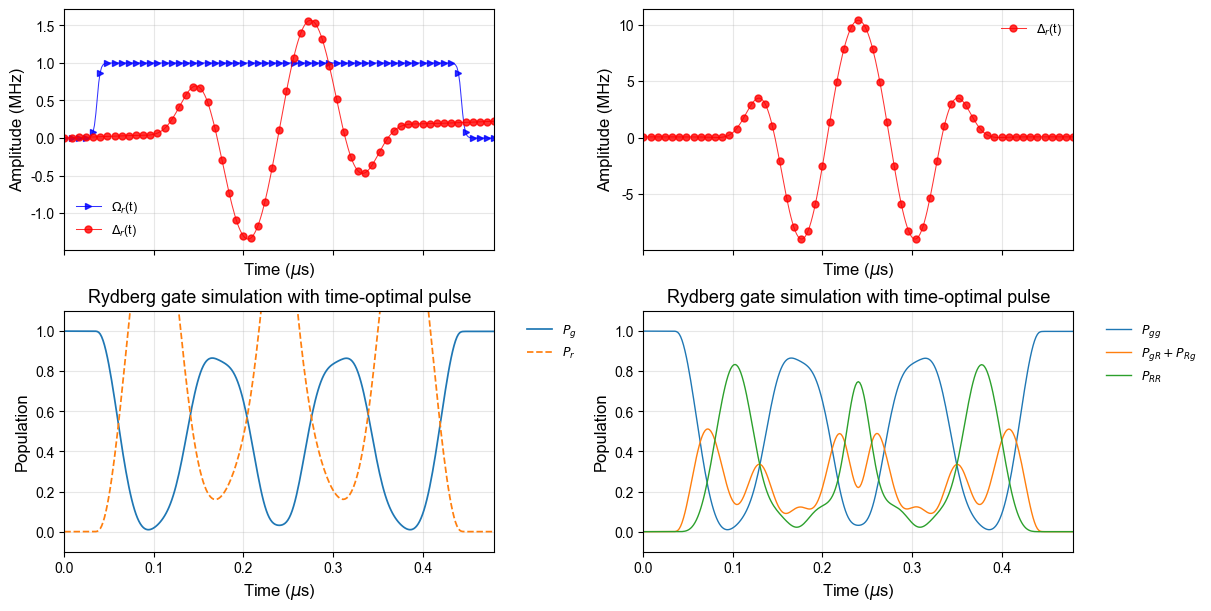

In [7]:
plotting_styles["Omega_r_pulse"]["markevery"] = 5
plotting_styles["Delta_r_pulse"]["markevery"] = 5
plt.rcParams.update(plt_config)

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=False, constrained_layout=True)
axes = axes.ravel()
# Plot the pulse shapes
pulse_dict = {
  'Omega_r': {'data': time_optimal_pulse_Omega_r, 'args': Omega_r_pulse_args, 
              'label': r'$\Omega_r$(t)', 'style': 'Omega_r_pulse', 'normalize_factor': amp_Omega_r},
  'Delta_r': {'data': time_optimal_pulse_phase_profile, 'args': Delta_r_pulse_args, 
              'label': r'$\Delta_r$(t)', 'style': 'Delta_r_pulse', 'normalize_factor': 1.0}
}

plot_pulse_shapes(
  ax = axes[0],
  tlist = tlist,
  pulse_dict = pulse_dict,
  title = None,
  xlabel = r"Time ($\mu$s)",
  ylabel = "Amplitude (MHz)",
  normalize_2pi = False,  # 使用每个脉冲自己的 normalize_factor
  ylim = None,
  grid_alpha = 0.3,
  # legend_config = legend_styles['compact'],
)

# Plot the pulse shapes of Delta_r
pulse_dict = {
  'Delta_r': {'data': time_optimal_pulse_Delta_r, 'args': Delta_r_pulse_args, 
              'label': r'$\Delta_r$(t)', 'style': 'Delta_r_pulse', 'normalize_factor': 2 * np.pi}
}

plot_pulse_shapes(
  ax = axes[1],
  tlist = tlist,
  pulse_dict = pulse_dict,
  title = None,
  xlabel = r"Time ($\mu$s)",
  ylabel = "Amplitude (MHz)",
  normalize_2pi = False,  # 使用每个脉冲自己的 normalize_factor
  ylim = None,
  grid_alpha = 0.3,
  # legend_config = legend_styles['compact'],
)
  
# Plot the population evolution
pop_list = [result.expect[0], result.expect[1]]
legend_list = [r"$P_g$", r"$P_r$"]

plot_population_evolution(
  ax = axes[2],
  tlist = tlist,
  pop_list = pop_list,
  legend_list = legend_list,
  plot_pulse = False,
  pulse_dict = {},
  title = r"Rydberg gate simulation with time-optimal pulse",
  xlabel = r"Time ($\mu$s)",
  ylabel = "Population",
  log_scale = False,
  xlim = None,
  ylim = None,
  grid_alpha = 0.3,
  show_legend = True,
  plotting_style_list = None,
)

# Plot the population evolution
pop_list = [result.expect[2], result.expect[3], result.expect[4]]
legend_list = [r"$P_{gg}$", r"$P_{gR} + P_{Rg}$", r"$P_{RR}$"]

plot_population_evolution(
  ax = axes[3],
  tlist = tlist,
  pop_list = pop_list,
  legend_list = legend_list,
  plot_pulse = False,
  pulse_dict = {},
  title = r"Rydberg gate simulation with time-optimal pulse",
  xlabel = r"Time ($\mu$s)",
  ylabel = "Population",
  log_scale = False,
  xlim = None,
  ylim = None,
  grid_alpha = 0.3,
  show_legend = True,
  plotting_style_list = [plotting_styles["pop_style_a"]],
)
